In [ ]:
# --- imports + setup ---
# run this script every time!

import torch
from controller import LSTMController
from utils import plot_activations, plot_activations_multi
from matplotlib import pyplot as plt

import sys
sys.path.append('..')

from QMC_mouseUSV.subglottal_pressure import subglottal_pressure
from QMC_mouseUSV.glottal_area import glottal_area
from QMC_mouseUSV.impingement_length import impingement_length
from QMC_mouseUSV.jet_speed import jet_speed_from_pressure
from QMC_mouseUSV.USVfreq import USVfreq

num_syllable_classes = 6

In [ ]:
model = LSTMController(num_syllable_classes=num_syllable_classes)
# --- fake input: 1 syllable, batch size 1 ---
syllable_id = torch.tensor([2])  # random placeholder syllable class

# --- forward pass through the LSTM ---
activations = model(syllable_id)
print("lstm output shape: " + str(activations.shape))

# unpacking the 4 channels in the order defined in controller.py
# (resp, PCAIA, CT, TA)
resp_activity = activations[..., 0]
PCAIA_activity = activations[..., 1]
CT_activity = activations[..., 2]
TA_activity = activations[..., 3]

# --- run thru the ported hakansson et al. model ---
pressure = subglottal_pressure(resp_activity)
g_area = glottal_area(PCAIA_activity, TA_activity)
imp_length = impingement_length(CT_activity, TA_activity)
speed = jet_speed_from_pressure(g_area, pressure)
predicted_f0 = USVfreq(speed, imp_length)

print("predicted f0 shape: " + str(predicted_f0.shape))
print("predicted f0 sample values: " + str(predicted_f0[0, :5]))

# --- fake ground turth (this is completely random lol) ---
fake_target_f0 = torch.rand_like(predicted_f0) * 50000 + 20000 # arbritrary but still plausible i think?

# --- loss & backward ---
# **REMINDER TO TRY OTHER LOSSES HERE (mse is like my default im sure there are other better ones)
loss = torch.nn.functional.mse_loss(predicted_f0, fake_target_f0)
print("loss: " + str(loss.item()))

loss.backward()

# --- check gradients actually reached the lstm's weights ---
for name, param in model.named_parameters():
    if param.grad is None:
        print("no gradient for " + name)
    else:
        print(f"{name}: grad norm = {param.grad.norm().item():.6f}")


lstm output shape: torch.Size([1, 100, 4])
predicted f0 shape: torch.Size([1, 100])
predicted f0 sample values: tensor([64050.2266, 65007.5938, 65511.9414, 65812.0234, 66005.9062],
       grad_fn=<SliceBackward0>)
loss: 723870464.0
embedding.weight: grad norm = 118818200.000000
lstm.weight_ih_l0: grad norm = 1488520192.000000
lstm.weight_hh_l0: grad norm = 480222720.000000
lstm.bias_ih_l0: grad norm = 477455424.000000
lstm.bias_hh_l0: grad norm = 477455424.000000
fc.weight: grad norm = 1953006592.000000
fc.bias: grad norm = 1917723392.000000


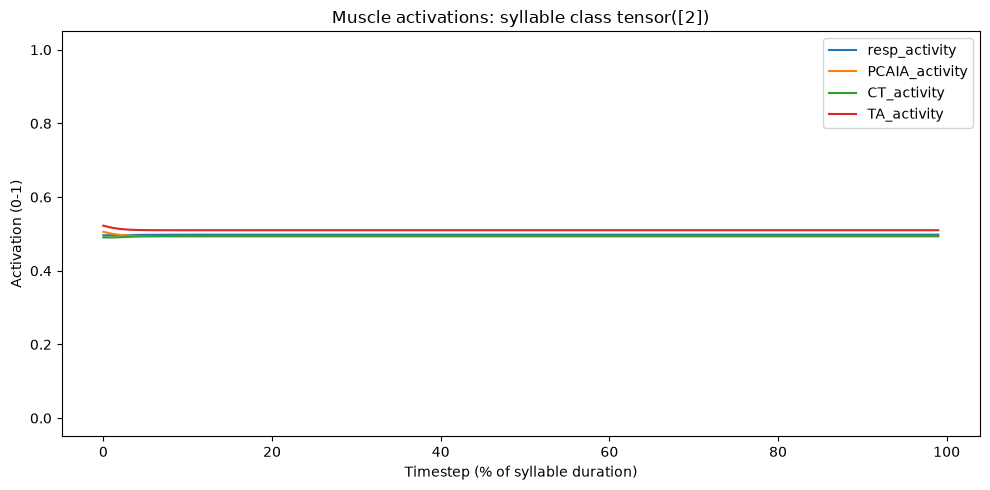

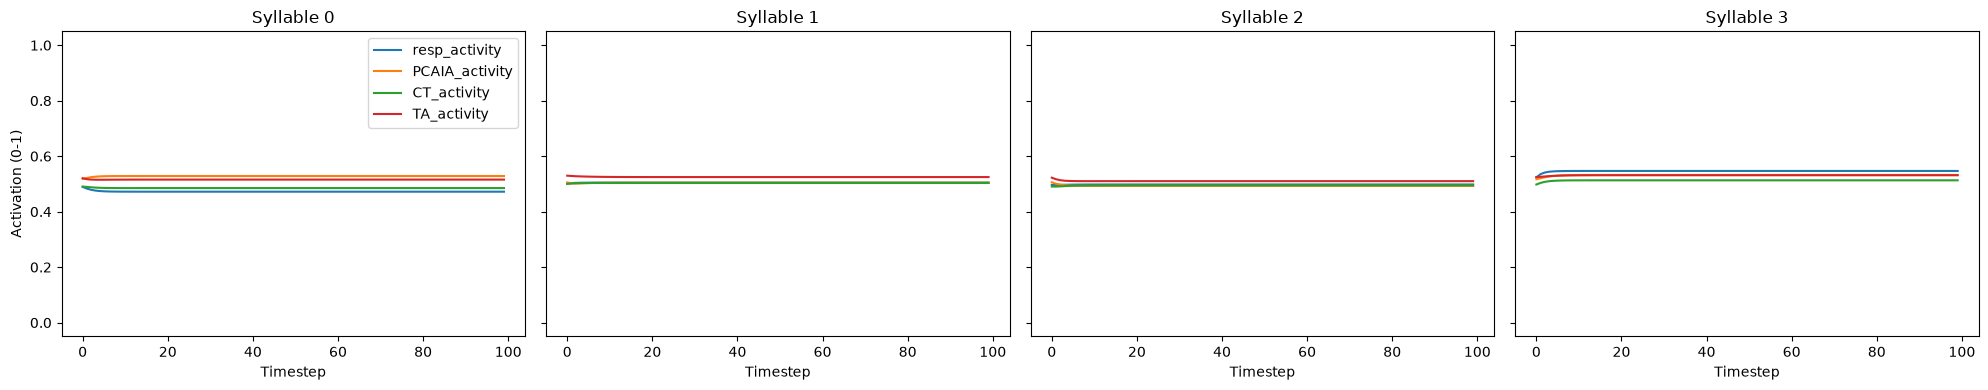

In [10]:
# --- visualizing the muscle activations ---

# single syllable
syllable_id = torch.tensor([2])
activations = model(syllable_id)
plot_activations(activations, syllable_id)

# compare a few syllables side by side
activations_dict = {}
for sid in [0, 1, 2, 3]:
    activations_dict[sid] = model(torch.tensor([sid]))
plot_activations_multi(activations_dict)

epoch 0: loss = 759520448.00
epoch 20: loss = 80087160.00
epoch 40: loss = 77204840.00
epoch 60: loss = 73322704.00
epoch 80: loss = 36394208.00
epoch 100: loss = 7699747.00
epoch 120: loss = 1061061.62
epoch 140: loss = 315383.34
epoch 160: loss = 203017.70
epoch 180: loss = 136201.58
epoch 200: loss = 93640.88
epoch 220: loss = 65114.52
epoch 240: loss = 45934.98
epoch 260: loss = 33266.43
epoch 280: loss = 24942.16
final loss: 19633.97


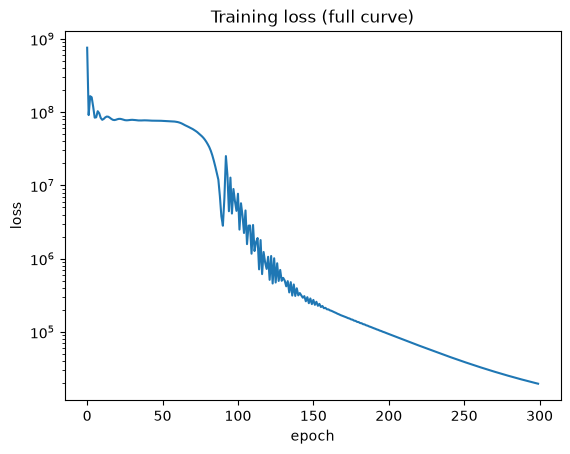

predicted f0 range: 30337.78125 59612.46484375
target f0 range: 30000.0 60000.0
beta range: 0.5543825626373291 0.5724331140518188


In [18]:
model = LSTMController(num_syllable_classes=num_syllable_classes)

# --- training loop with completely synethetic target f0 ---

# REMEMBER TO CHANGE LR its too high rn (set maybe to like 1e-3?)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

syllable_id = torch.tensor([2])
fake_target_f0 = torch.linspace(30000, 60000, 100).unsqueeze(0)  # smooth curve, 30kHz -> 60kHz over the syllable

losses = []

for epoch in range(300):
    optimizer.zero_grad()

    activations = model(syllable_id)
    resp_activity = activations[..., 0]
    PCAIA_activity = activations[..., 1]
    CT_activity = activations[..., 2]
    TA_activity = activations[..., 3]

    pressure = subglottal_pressure(resp_activity)
    g_area = glottal_area(PCAIA_activity, TA_activity)
    imp_length = impingement_length(CT_activity, TA_activity)
    speed = jet_speed_from_pressure(g_area, pressure)
    predicted_f0 = USVfreq(speed, imp_length)

    loss = torch.nn.functional.mse_loss(predicted_f0, fake_target_f0)
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    if epoch % 20 == 0:
        print(f"epoch {epoch}: loss = {loss.item():.2f}")

print(f"final loss: {losses[-1]:.2f}")

# graph loss over time
plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.yscale("log")  # helpful when values span multiple orders of magnitude
plt.title("Training loss (full curve)")
plt.show()

# check the mucsle activations after training
with torch.no_grad():
    activations_start_check = model(syllable_id)
    pred_check = USVfreq(
        jet_speed_from_pressure(
            glottal_area(activations_start_check[...,1], activations_start_check[...,3]),
            subglottal_pressure(activations_start_check[...,0])
        ),
        impingement_length(activations_start_check[...,2], activations_start_check[...,3])
    )
    print("predicted f0 range:", pred_check.min().item(), pred_check.max().item())
    print("target f0 range:", fake_target_f0.min().item(), fake_target_f0.max().item())

    g_area_check = glottal_area(activations_start_check[...,1], activations_start_check[...,3])
    tracheal_diameter = 2 * torch.sqrt(torch.tensor(0.95e-6) / torch.pi)
    glottal_diameter = 2 * torch.sqrt(g_area_check / torch.pi)
    beta_check = glottal_diameter / tracheal_diameter
    print("beta range:", beta_check.min().item(), beta_check.max().item())